# Task B: Damage Level Classification

Create a damage level classifier for the `hurricane-matthew` disaster.

## Feature Engineering

Which features are useful for this classification task? Construct them here.

We have around 5000 points with a label one, and we have 1500 points with a label of two. There are two ways we can work with this knowledge. First, we can built a dataset where we have the same number of datapoints for each label. Then, we can try weighing the inputs by their length to make a less-occuring label have a higher impact on the direction of the model.

1    5236
0    2631
3    1740
2 1544nt64

### DataSet1: Same Number of Datapoints per Label

In [1]:
import numpy as np

graph_mat = np.load("gca_matrices/0_graph_mat.npy")
state_mat = np.load("gca_matrices/0_state_mat.npy")
properties_mat = np.load("gca_matrices/0_properties_mat.npy")

print("Graph Matrix:", graph_mat)
print("State Matrix:", state_mat)
print("Properties Matrix:", properties_mat)


Graph Matrix: [[0 1 0 ... 0 0 1]
 [1 0 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 1 0 1]
 [1 0 0 ... 0 1 0]]
State Matrix: [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 ...
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]
Properties Matrix: [[1.00097133 3.99528408]
 [1.00399761 4.0016285 ]
 [0.99488729 3.98987363]
 ...
 [1.00341901 3.99765464]
 [0.9917438  3.98350947]
 [1.00371543 4.00145962]]


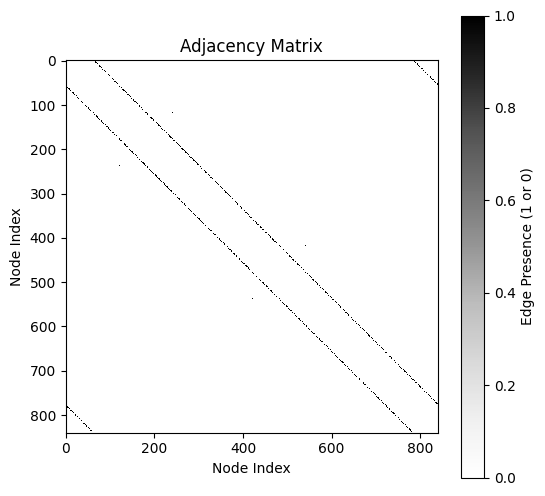

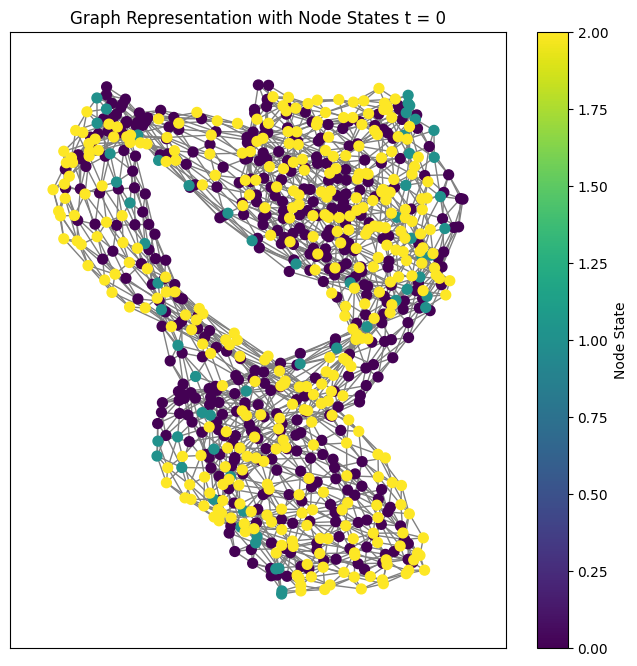

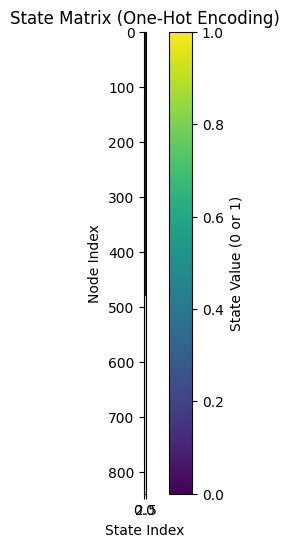

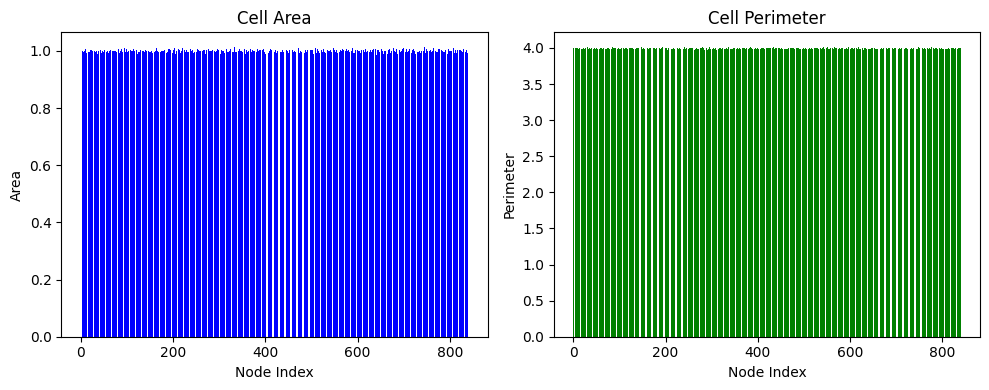

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Load matrices
graph_mat = np.load("gca_matrices/0_graph_mat.npy")
state_mat = np.load("gca_matrices/0_state_mat.npy")
properties_mat = np.load("gca_matrices/0_properties_mat.npy")

# Visualize Graph Matrix
def plot_graph(graph_mat, state_mat):
    """
    Visualizes the adjacency graph with node colors based on state matrix.
    """
    # Create a graph from adjacency matrix
    g = nx.from_numpy_array(graph_mat, create_using=nx.Graph)

    # Node colors based on state
    node_colors = [np.argmax(state_mat[i]) for i in range(state_mat.shape[0])]
    unique_states = np.unique(node_colors)

    # Create a figure with dedicated axes
    fig, ax = plt.subplots(figsize=(8, 8))
    pos = nx.spring_layout(g)  # Spring layout for visualization

    # Draw the graph
    nodes = nx.draw_networkx_nodes(
        g,
        pos,
        node_color=node_colors,
        cmap=plt.cm.viridis,
        node_size=50,  # Further reduced node size
        ax=ax
    )
    nx.draw_networkx_edges(g, pos, edge_color="gray", ax=ax)

    # Add a custom colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=unique_states.min(), vmax=unique_states.max()))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Node State")

    plt.title("Graph Representation with Node States t = 0")
    plt.show()


# Plotting adjacency matrix
plt.figure(figsize=(6, 6))
plt.title("Adjacency Matrix")
plt.imshow(graph_mat, cmap="Greys", interpolation="none")
plt.colorbar(label="Edge Presence (1 or 0)")
plt.xlabel("Node Index")
plt.ylabel("Node Index")
plt.show()

# Plot the graph with states
plot_graph(graph_mat, state_mat)

# Visualize State Matrix
plt.figure(figsize=(6, 6))
plt.title("State Matrix (One-Hot Encoding)")
plt.imshow(state_mat, cmap="viridis", interpolation="none")
plt.colorbar(label="State Value (0 or 1)")
plt.xlabel("State Index")
plt.ylabel("Node Index")
plt.show()

# Visualize Properties Matrix
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(properties_mat.shape[0]), properties_mat[:, 0], color="blue")
plt.title("Cell Area")
plt.xlabel("Node Index")
plt.ylabel("Area")

plt.subplot(1, 2, 2)
plt.bar(range(properties_mat.shape[0]), properties_mat[:, 1], color="green")
plt.title("Cell Perimeter")
plt.xlabel("Node Index")
plt.ylabel("Perimeter")

plt.tight_layout()
plt.show()


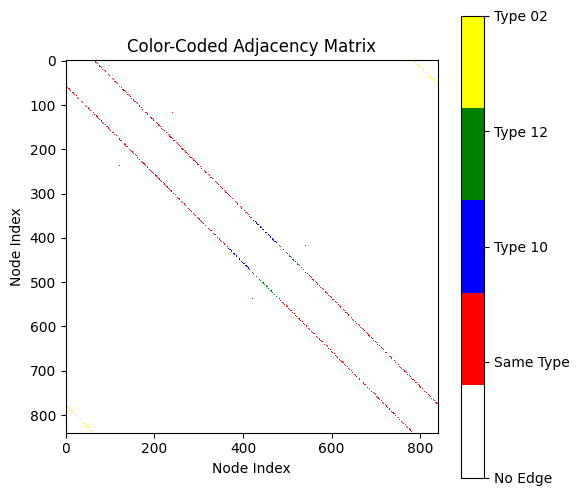

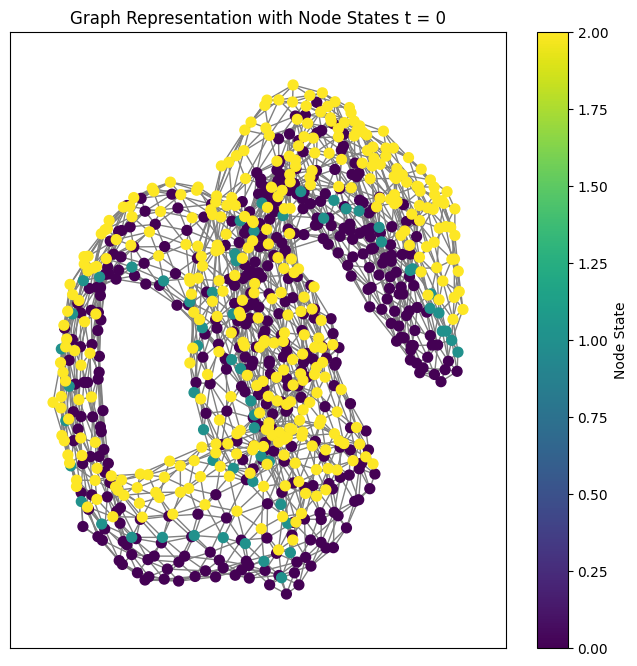

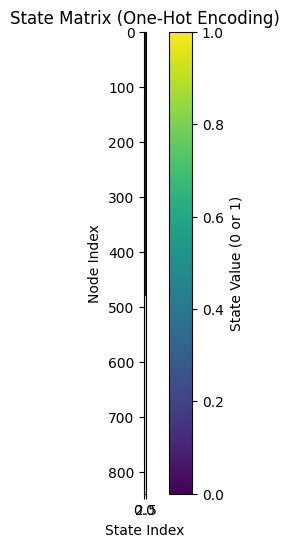

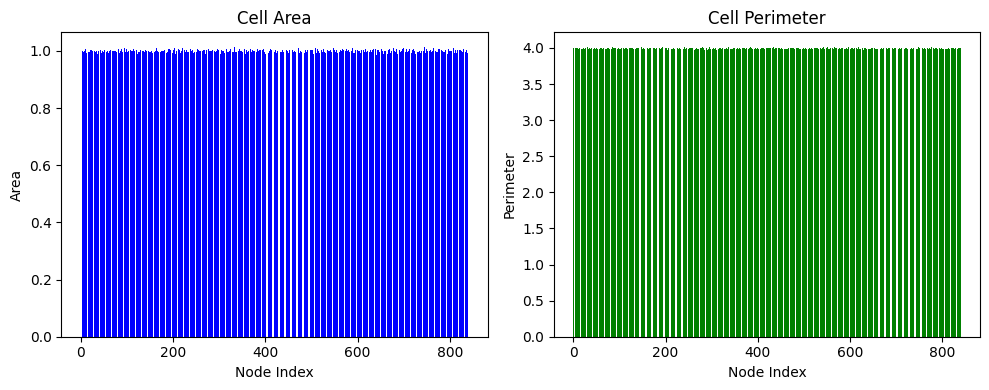

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Load matrices
graph_mat = np.load("matrices/0_graph_mat.npy")
state_mat = np.load("matrices/0_state_mat.npy")
properties_mat = np.load("matrices/0_properties_mat.npy")

def color_code_adjacency_matrix(graph_mat, state_mat):
    """
    Color-codes the adjacency matrix based on node types.
    """
    # Determine node types based on the state matrix
    node_types = [np.argmax(state_mat[i]) for i in range(state_mat.shape[0])]

    # Create a color-coded matrix for adjacency
    color_coded_mat = np.zeros_like(graph_mat, dtype=int)  # Initialize with 0 for no edge

    for i in range(graph_mat.shape[0]):
        for j in range(graph_mat.shape[1]):
            if graph_mat[i, j] == 1:  # Check if there is an edge
                type_i = node_types[i]
                type_j = node_types[j]

                # Assign colors based on type combinations
                if type_i == type_j:
                    color_coded_mat[i, j] = 1  # Same type (red)
                elif {type_i, type_j} == {1, 0}:
                    color_coded_mat[i, j] = 2  # Type 10 (blue)
                elif {type_i, type_j} == {1, 2}:
                    color_coded_mat[i, j] = 3  # Type 12 (green)
                elif {type_i, type_j} == {0, 2}:
                    color_coded_mat[i, j] = 4  # Type 02 (yellow)

    return color_coded_mat


# Plotting adjacency matrix with color coding
color_coded_matrix = color_code_adjacency_matrix(graph_mat, state_mat)

# Define a colormap for the adjacency matrix
from matplotlib.colors import ListedColormap

# Custom colormap: white for no edge, red, blue, green, yellow for the types
cmap = ListedColormap(["white", "red", "blue", "green", "yellow"])

plt.figure(figsize=(6, 6))
plt.title("Color-Coded Adjacency Matrix")
plt.imshow(color_coded_matrix, cmap=cmap, interpolation="none")
cbar = plt.colorbar(ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(["No Edge", "Same Type", "Type 10", "Type 12", "Type 02"])  # Custom labels
plt.xlabel("Node Index")
plt.ylabel("Node Index")
plt.show()
# Visualize Graph Representation
def plot_graph(graph_mat, state_mat):
    """
    Visualizes the adjacency graph with node colors based on state matrix.
    """
    # Create a graph from adjacency matrix
    g = nx.from_numpy_array(graph_mat, create_using=nx.Graph)

    # Node colors based on state
    node_colors = [np.argmax(state_mat[i]) for i in range(state_mat.shape[0])]
    unique_states = np.unique(node_colors)

    # Create a figure with dedicated axes
    fig, ax = plt.subplots(figsize=(8, 8))
    pos = nx.spring_layout(g)  # Spring layout for visualization

    # Draw the graph
    nodes = nx.draw_networkx_nodes(
        g,
        pos,
        node_color=node_colors,
        cmap=plt.cm.viridis,
        node_size=50,  # Further reduced node size
        ax=ax
    )
    nx.draw_networkx_edges(g, pos, edge_color="gray", ax=ax)

    # Add a custom colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=unique_states.min(), vmax=unique_states.max()))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Node State")

    plt.title("Graph Representation with Node States t = 0")
    plt.show()


# Plot the graph with states
plot_graph(graph_mat, state_mat)

# Visualize State Matrix
plt.figure(figsize=(6, 6))
plt.title("State Matrix (One-Hot Encoding)")
plt.imshow(state_mat, cmap="viridis", interpolation="none")
plt.colorbar(label="State Value (0 or 1)")
plt.xlabel("State Index")
plt.ylabel("Node Index")
plt.show()

# Visualize Properties Matrix
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(properties_mat.shape[0]), properties_mat[:, 0], color="blue")
plt.title("Cell Area")
plt.xlabel("Node Index")
plt.ylabel("Area")

plt.subplot(1, 2, 2)
plt.bar(range(properties_mat.shape[0]), properties_mat[:, 1], color="green")
plt.title("Cell Perimeter")
plt.xlabel("Node Index")
plt.ylabel("Perimeter")

plt.tight_layout()
plt.show()


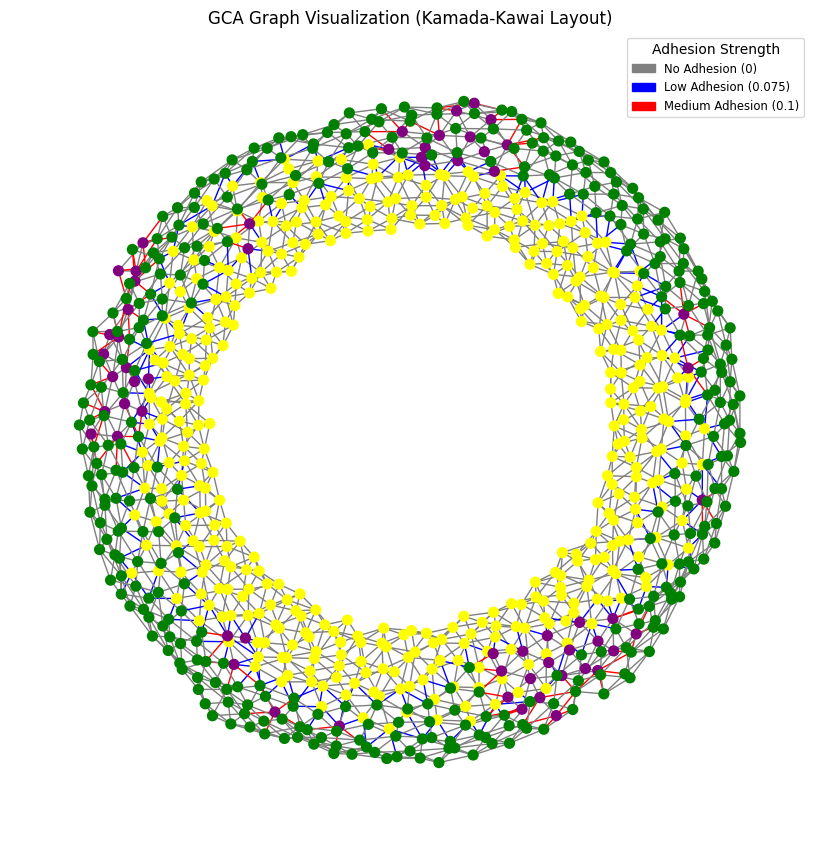

In [1]:
import os
import numpy as np
import networkx as nx
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Params for the GCA model
v0 = [0.75, 1.5, 0.0]  # Motility for Pdgfra-, Pdgfra+, epithelium
Dr = 40  # Inverse of persistence timescale for motility
kappa_A = 0.3  # Coefficient for deviation from target area
kappa_P = 0.05  # Coefficient for deviation from target perimeter
a = 0.2  # Maximal radius to engage in repulsion
k = 2  # Coefficient of repulsion
# Adhesion energies
EM, EG, MG = 0.075, 0.075, 0.1  # Heterotypic
MM, GG, EE = 0.0, 0.0, 0.0  # Homotypic

# Function to load matrices from a directory
def load_matrices(directory, timepoint):
    """
    Load the graph, properties, and state matrices for a specific timepoint.
    """
    graph_mat = np.load(os.path.join(directory, f"{timepoint}_graph_mat.npy"))
    properties_mat = np.load(os.path.join(directory, f"{timepoint}_properties_mat.npy"))
    state_mat = np.load(os.path.join(directory, f"{timepoint}_state_mat.npy"))
    return graph_mat, properties_mat, state_mat

# Initialize GCA graph with constants
def initialize_gca(graph_mat, properties_mat, state_mat):
    """
    Create a NetworkX graph with node and edge properties for GCA initialization.
    """
    # Create a graph from the adjacency matrix
    g = nx.from_numpy_array(graph_mat, create_using=nx.Graph)

    # Add node properties
    for i, (area, perimeter) in enumerate(properties_mat):
        cell_type = np.argmax(state_mat[i])  # Get the dominant cell type
        g.nodes[i]["cell_type"] = cell_type
        g.nodes[i]["motility"] = v0[cell_type]  # Assign motility based on cell type
        g.nodes[i]["area"] = area
        g.nodes[i]["perimeter"] = perimeter
        g.nodes[i]["persistence"] = Dr
        g.nodes[i]["kappa_A"] = kappa_A
        g.nodes[i]["kappa_P"] = kappa_P

    # Add edge properties
    for u, v in g.edges():
        type_u, type_v = g.nodes[u]["cell_type"], g.nodes[v]["cell_type"]
        if type_u == type_v:  # Homotypic adhesion
            if type_u == 0:
                adhesion = EE
            elif type_u == 1:
                adhesion = MM
            elif type_u == 2:
                adhesion = GG
        else:  # Heterotypic adhesion
            if {type_u, type_v} == {0, 1}:
                adhesion = EM
            elif {type_u, type_v} == {0, 2}:
                adhesion = EG
            elif {type_u, type_v} == {1, 2}:
                adhesion = MG
        g.edges[u, v]["adhesion"] = adhesion
        g.edges[u, v]["repulsion_radius"] = a
        g.edges[u, v]["repulsion_coefficient"] = k

    return g

# Visualization function
def visualize_gca_kamada_kawai(graph):
    """
    Visualize the GCA graph using the Kamada-Kawai layout.
    Nodes are color-coded by cell type, and edges are categorized into distinct colors
    based on exact adhesion strength thresholds.
    """
    pos = nx.kamada_kawai_layout(graph)  # Use Kamada-Kawai layout

    # Node colors based on cell type
    node_colors = [
        "yellow" if graph.nodes[i]["cell_type"] == 0 else
        "purple" if graph.nodes[i]["cell_type"] == 1 else "green"
        for i in graph.nodes
    ]

    # Edge colors differentiated by exact adhesion strength thresholds
    edge_colors = []
    for u, v, data in graph.edges(data=True):
        adhesion = data["adhesion"]
        if adhesion == 0:  # No adhesion
            edge_colors.append("gray")
        elif adhesion == 0.075:  # Low adhesion
            edge_colors.append("blue")
        elif adhesion == 0.1:  # Medium adhesion
            edge_colors.append("red")
            
    # Plot the graph
    plt.figure(figsize=(8, 8))
    nx.draw(
        graph,
        pos,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=50,
        with_labels=False,
    )

    # Add a legend for edge colors
    legend_patches = [
        mpatches.Patch(color="gray", label="No Adhesion (0)"),
        mpatches.Patch(color="blue", label="Low Adhesion (0.075)"),
        mpatches.Patch(color="red", label="Medium Adhesion (0.1)"),
    ]
    plt.legend(handles=legend_patches, loc="upper right", title="Adhesion Strength", fontsize="small")

    plt.title("GCA Graph Visualization (Kamada-Kawai Layout)")
    plt.show()


# Directory containing .npy files
directory = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV-GutSPV5-GNN/1/matrices"
timepoint = "2000"  # Example: Load timepoint 0

# Load matrices and initialize GCA graph
graph_mat, properties_mat, state_mat = load_matrices(directory, timepoint)
gca_graph = initialize_gca(graph_mat, properties_mat, state_mat)

# Visualize the GCA graph with Kamada-Kawai layout
visualize_gca_kamada_kawai(gca_graph)



In [1]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [61]:
import os
import networkx as nx
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

from pysr import PySRRegressor
import torch
import numpy as np
import torch.nn as nn
from torch.optim import Adam
from torch_geometric.utils import from_networkx, add_self_loops
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.nn import MessagePassing


# Function to load matrices from a directory
def load_matrices(directory, timepoint):
    """
    Load the graph, properties, and state matrices for a specific timepoint.
    """
    graph_mat = np.load(os.path.join(directory, f"{timepoint}_graph_mat.npy"))
    properties_mat = np.load(os.path.join(directory, f"{timepoint}_properties_mat.npy"))
    state_mat = np.load(os.path.join(directory, f"{timepoint}_state_mat.npy"))
    return graph_mat, properties_mat, state_mat

# Initialize GCA graph with dynamically parsed params
def initialize_gca(graph_mat, properties_mat, state_mat, params):
    """
    Create a NetworkX graph with node and edge properties for GCA initialization.
    """
    # Create a graph from the adjacency matrix
    g = nx.from_numpy_array(graph_mat, create_using=nx.Graph)

    # Access parameters
    v0 = params["v0"]
    Dr = params["Dr"]
    kappa_A = params["kappa_A"]
    kappa_P = params["kappa_P"]
    a = params["a"]
    k = params["k"]
    EE = params["EE"]
    MM = params["MM"]
    GG = params["GG"]
    EM = params["EM"]
    EG = params["EG"]
    MG = params["MG"]

    # Add node properties
    for i, (area, perimeter) in enumerate(properties_mat):
        cell_type = np.argmax(state_mat[i])  # Get the dominant cell type
        g.nodes[i]["cell_type"] = cell_type
        g.nodes[i]["motility"] = v0[cell_type]  # Assign motility based on cell type
        g.nodes[i]["area"] = area
        g.nodes[i]["perimeter"] = perimeter
        g.nodes[i]["persistence"] = Dr
        g.nodes[i]["kappa_A"] = kappa_A
        g.nodes[i]["kappa_P"] = kappa_P

    # Add edge properties
    for u, v in g.edges():
        type_u, type_v = g.nodes[u]["cell_type"], g.nodes[v]["cell_type"]
        if type_u == type_v:  # Homotypic adhesion
            adhesion = {0: EE, 1: MM, 2: GG}.get(type_u, 0)
        else:  # Heterotypic adhesion
            adhesion = {(0, 1): EM, (0, 2): EG, (1, 2): MG}.get(tuple(sorted((type_u, type_v))), 0)
        g.edges[u, v]["adhesion"] = adhesion
        g.edges[u, v]["repulsion_radius"] = a
        g.edges[u, v]["repulsion_coefficient"] = k

    return g

# Parse parameters from .py files
def parse_parameters(param_path):
    params = {}
    print(f"Parsing parameters from {param_path}")
    with open(param_path, "r") as f:
        exec(f.read(), {}, params)  # Safely execute the file content within a restricted namespace
    print(f"Parsed parameters: {params}")
    return params

# Pre-initialize GCAs for all timepoints and directories
def initialize_gca_once(data_dirs, param_files, timepoints, timepoint_interval):
    print("Pre-initializing GCAs and matrices for all timepoints...")
    gca_data = []
    for dir_idx, (data_dir, param_file) in enumerate(zip(data_dirs, param_files)):
        print(f"Processing directory {data_dir} with parameter file {param_file}...")
        params = parse_parameters(param_file)
        fold_data = {}
        for t in range(0, timepoints, timepoint_interval):
            graph_mat, properties_mat, state_mat = load_matrices(data_dir, t)
            gca_graph = initialize_gca(graph_mat, properties_mat, state_mat, params)
            fold_data[t] = {
                "gca_graph": gca_graph,
                "state_mat": state_mat
            }
        gca_data.append(fold_data)
    print("Pre-initialization complete.")
    return gca_data

# Define GNN model
# Define GNN model
class GNNTransitionRule(MessagePassing):
    def __init__(self, node_dim, edge_dim, hidden_dim, output_dim):
        super(GNNTransitionRule, self).__init__(aggr="add")
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * node_dim + edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, edge_dim),
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(node_dim + edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x, edge_index, edge_attr):
        """
        Forward pass for the GNN layer.
        Dynamically adjusts edge attributes to match edge index size.
        """
        # Add self-loops to the graph
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        if edge_attr is not None:
            num_existing_edges = edge_attr.size(0)
            num_edges = edge_index.size(1)

            if num_existing_edges < num_edges:
                # Add zero-padding for missing edge attributes
                num_missing_edges = num_edges - num_existing_edges
                padding = torch.zeros(
                    (num_missing_edges, edge_attr.size(1)), device=edge_attr.device
                )
                edge_attr = torch.cat([edge_attr, padding], dim=0)

        else:
            # Initialize edge attributes if none exist
            edge_attr = torch.zeros((edge_index.size(1), 1), device=x.device)

        # Debugging: Log sizes for edge attributes and indices
     #   print(f"Edge index size: {edge_index.size()}, Edge attr size: {edge_attr.size()}")

        # Ensure sizes match
        assert edge_attr.size(0) == edge_index.size(1), (
            f"Mismatch between edge attributes ({edge_attr.size(0)}) and edge indices ({edge_index.size(1)})"
        )

        # Propagate messages through the GNN
        edge_attr = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        return edge_attr

    def message(self, x_i, x_j, edge_attr):
        """
        Compute messages for the GNN layer.
        """
        edge_input = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return self.edge_mlp(edge_input)

    def update(self, aggr_out, x):
        """
        Update node features based on aggregated messages.
        """
        node_input = torch.cat([x, aggr_out], dim=-1)
        return self.node_mlp(node_input)

# GNCA wrapper model
class GNCA(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, output_dim):
        super(GNCA, self).__init__()
        self.transition_rule = GNNTransitionRule(node_dim, edge_dim, hidden_dim, output_dim)

    def forward(self, x, edge_index, edge_attr):
        return self.transition_rule(x, edge_index, edge_attr)

# Directory containing .npy files
def k_fold_training(data_dirs, gca_data, timepoint_interval, node_dim, edge_dim, hidden_dim, output_dim, epochs, learning_rate, k_folds):
    fold_results = []
    best_model = None
    best_loss = float('inf')  # Initialize to a very high value

    for fold in range(k_folds):
        print(f"Starting Fold {fold + 1}/{k_folds}")

        validation_data = gca_data[fold]
        training_data = {i: gca_data[i] for i in range(len(data_dirs)) if i != fold}

        model = GNCA(node_dim, edge_dim, hidden_dim, output_dim)
        optimizer = Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()

        for epoch in range(epochs):
            print(f"Epoch {epoch + 1}/{epochs} - Fold {fold + 1}")
            epoch_loss = 0.0

            for train_set in training_data.values():
                for gca_graph in train_set.values():
                    data = from_networkx(gca_graph["gca_graph"])

                    node_features = [
                        [
                            gca_graph["gca_graph"].nodes[i]["cell_type"],
                            gca_graph["gca_graph"].nodes[i]["motility"],
                            gca_graph["gca_graph"].nodes[i]["area"],
                            gca_graph["gca_graph"].nodes[i]["perimeter"],
                            gca_graph["gca_graph"].nodes[i]["persistence"],
                            gca_graph["gca_graph"].nodes[i]["kappa_A"],
                            gca_graph["gca_graph"].nodes[i]["kappa_P"],
                        ]
                        for i in range(len(gca_graph["gca_graph"].nodes))
                    ]
                    data.x = torch.tensor(node_features, dtype=torch.float32)

                    edge_features = [d["adhesion"] for _, _, d in gca_graph["gca_graph"].edges(data=True)]
                    data.edge_attr = torch.tensor(edge_features, dtype=torch.float32).unsqueeze(-1)

                    target = torch.tensor(gca_graph["state_mat"], dtype=torch.float32)

                    optimizer.zero_grad()
                    pred = model(data.x, data.edge_index, data.edge_attr)

                    loss = criterion(pred, target)
                    loss.backward()
                    optimizer.step()

                    epoch_loss += loss.item()

            print(f"Epoch Loss: {epoch_loss:.4f}")

        validation_loss = 0.0
        with torch.no_grad():
            for gca_graph in validation_data.values():
                data = from_networkx(gca_graph["gca_graph"])

                node_features = [
                    [
                        gca_graph["gca_graph"].nodes[i]["cell_type"],
                        gca_graph["gca_graph"].nodes[i]["motility"],
                        gca_graph["gca_graph"].nodes[i]["area"],
                        gca_graph["gca_graph"].nodes[i]["perimeter"],
                        gca_graph["gca_graph"].nodes[i]["persistence"],
                        gca_graph["gca_graph"].nodes[i]["kappa_A"],
                        gca_graph["gca_graph"].nodes[i]["kappa_P"],
                    ]
                    for i in range(len(gca_graph["gca_graph"].nodes))
                ]
                data.x = torch.tensor(node_features, dtype=torch.float32)

                edge_features = [d["adhesion"] for _, _, d in gca_graph["gca_graph"].edges(data=True)]
                data.edge_attr = torch.tensor(edge_features, dtype=torch.float32).unsqueeze(-1)

                target = torch.tensor(gca_graph["state_mat"], dtype=torch.float32)
                pred = model(data.x, data.edge_index, data.edge_attr)

                validation_loss += criterion(pred, target).item()

        fold_avg_loss = validation_loss / len(validation_data)
        fold_results.append(fold_avg_loss)
        print(f"Fold {fold + 1} Validation Loss: {fold_avg_loss:.4f}")

        # Check if this fold is the best
        if fold_avg_loss < best_loss:
            best_loss = fold_avg_loss
            best_model = model

    # Save the best model
    if best_model is not None:
        torch.save(best_model.state_dict(), "best_model.pth")
        print(f"Best model saved with validation loss: {best_loss:.4f}")
    else:
        print("No best model found. Ensure the training loop is functioning correctly.")

    return fold_results

    
if __name__ == "__main__":
    data_dirs = [
        f"/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV-GutSPV6-simulations/output_Fig5l_matrix/{i}"
        for i in range(1, 7)
    ]
    param_files = [
        f"/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV-GutSPV6-simulations/parameters/Fig5I/{i}.py"
        for i in range(1, 7)
    ]
    timepoints = 500
    timepoint_interval = 4
    node_dim = 7
    edge_dim = 1
    hidden_dim = 16
    output_dim = 3
    epochs = 10
    learning_rate = 1e-3
    k_folds = 6

    gca_data = initialize_gca_once(data_dirs, param_files, timepoints, timepoint_interval)

    fold_losses = k_fold_training(
        data_dirs, gca_data, timepoint_interval, node_dim, edge_dim, hidden_dim, output_dim, epochs, learning_rate, k_folds
    )

    print("K-Fold Validation Losses:", fold_losses)


Pre-initializing GCAs and matrices for all timepoints...
Processing directory /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV-GutSPV6-simulations/output_Fig5l_matrix/1 with parameter file /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV-GutSPV6-simulations/parameters/Fig5I/1.py...
Parsing parameters from /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV-GutSPV6-simulations/parameters/Fig5I/1.py
Parsed parameters: {'domain_size': [60, 14], 'lumen_thickness': 6, 'mes_thickness': [1, 0, 0], 'mes_density': [0.0, 1.0, 1.0], 'init_noise': 0.05, 'rng_seed': 1, 'dt': 0.25, 'tMax': 501, 'A0': [0.5, 0.9, 0.5], 'P0': [3.722, 3.812, 3.722], 'v0': [1.5, 7, 0.2], 'Dr': 40, 'kappa_A': 0.3, 'kappa_P': 0.05, 'a': 0.2, 'k': 2, 'EM': 0.09, 'EG': 0.1, 'MG': 0.075, 'MM': 0.0, 'GG': 0.0, 'EE': 0.0, 'W': ([0.0, 0.075, 0.09], [0.075, 0.0, 0.1], [0.09, 0.1, 0.0])}
Processing directory /Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV-GutSPV6-simulations/output_Fig5l_m

In [ ]:
from pysr import PySRRegressor
import torch

def run_symbolic_regression(saved_model_path, data_dirs, gca_data, node_dim, edge_dim, hidden_dim, output_dim):
    """
    Load the saved best model and perform symbolic regression on its predictions.
    
    Args:
        saved_model_path (str): Path to the saved model file.
        data_dirs (list): List of directories containing data.
        gca_data (list): Pre-initialized GCA data.
        node_dim (int): Dimension of node features.
        edge_dim (int): Dimension of edge features.
        hidden_dim (int): Hidden layer dimension.
        output_dim (int): Output dimension.
    """
    # Load the saved model
    model = GNCA(node_dim, edge_dim, hidden_dim, output_dim)
    model.load_state_dict(torch.load(saved_model_path))
    model.eval()  # Set model to evaluation mode
    print(f"Loaded model from {saved_model_path}.")

    # Collect predictions and targets
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for fold in range(len(gca_data)):
            validation_data = gca_data[fold]
            for gca_graph in validation_data.values():
                data = from_networkx(gca_graph["gca_graph"])

                # Extract node features
                node_features = [
                    [
                        gca_graph["gca_graph"].nodes[i]["cell_type"],
                        gca_graph["gca_graph"].nodes[i]["motility"],
                        gca_graph["gca_graph"].nodes[i]["area"],
                        gca_graph["gca_graph"].nodes[i]["perimeter"],
                        gca_graph["gca_graph"].nodes[i]["persistence"],
                        gca_graph["gca_graph"].nodes[i]["kappa_A"],
                        gca_graph["gca_graph"].nodes[i]["kappa_P"],
                    ]
                    for i in range(len(gca_graph["gca_graph"].nodes))
                ]
                data.x = torch.tensor(node_features, dtype=torch.float32)

                # Extract edge features
                edge_features = [d["adhesion"] for _, _, d in gca_graph["gca_graph"].edges(data=True)]
                data.edge_attr = torch.tensor(edge_features, dtype=torch.float32).unsqueeze(-1)

                # Target and prediction
                target = torch.tensor(gca_graph["state_mat"], dtype=torch.float32)
                pred = model(data.x, data.edge_index, data.edge_attr)

                # Collect predictions and targets
                all_predictions.append(pred.numpy())
                all_targets.append(target.numpy())

    # Prepare data for symbolic regression
    all_predictions = np.vstack(all_predictions)
    all_targets = np.vstack(all_targets)

    # Perform symbolic regression with PySR
    print("Running symbolic regression...")
    model = PySRRegressor(
        niterations=1000,
        binary_operators=["+", "-", "*", "/", "pow"],
        unary_operators=["exp", "log", "sin", "cos", "tan", "abs"],
        loss="loss(x, y) = (x - y)^2",
        populations=5,
    )
    model.fit(all_predictions, all_targets)
    print("Symbolic regression complete.")
    print("Discovered equations:")
    print(model)

if __name__ == "__main__":
    # Ensure GCA data and directories are initialized
    #gca_data = initialize_gca_once(data_dirs, param_files, timepoints, timepoint_interval)

    # Path to the saved best model
    saved_model_path = "best_model.pth"

    # Run symbolic regression
    run_symbolic_regression(
        saved_model_path,
        data_dirs,
        gca_data,
        node_dim,
        edge_dim,
        hidden_dim,
        output_dim,
    )



/var/folders/_2/xkrjp2q52cn8mxmjrvp731500000gq/T/ipykernel_26999/838105752.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(saved_model_

Loaded model from best_model.pth.
Running symbolic regression...
Compiling Julia backend...


/Users/sophia01px2019/miniforge3/envs/new_env/lib/python3.9/site-packages/pysr/sr.py:915: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/Users/sophia01px2019/miniforge3/envs/new_env/lib/python3.9/site-packages/pysr/sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/sophia01px2019/miniforge3/envs/new_env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sophia01px2019/miniforge3/envs/new_env/lib/python3.9/site-packages/pysr/sr.py:2029: UserWarning: Note: you are running with more than 10,000 datapoints. You should consider turning on batching (https://astroautomata.com/PySR/options/#batch


Expressions evaluated per second: 0.000e+00
Head worker occupation: 0.0%
Progress: 0 / 15000 total iterations (0.000%)
Best equations for output 1


## Model Training

Decide on an appropriate model and train it here. It may be necessary to compare between different types of models, and also tune hyperparameters later.

In [ ]:
X = hurricane_features.drop('Label', axis=1)
y = hurricane_features['Label']

#Scaling and Normalizing the data so that all feature data is between 0 and 1

scaler = MinMaxScaler(feature_range = (0,1))
sn_X = scaler.fit_transform(X)
sn_X = pd.DataFrame(sn_X, columns=X.columns, index=X.index)

sn_X.describe()

### CNN for Hurricane Dataset

In [11]:
import os
import numpy as np

folder_path = "/Users/sophia01px2019/Downloads/gartner_lab_rotation/GutSPV/Fig5I_1736525348_size-20_activ-[0.75,1.5,0.0]"
# Find all .npy files in the folder
npy_files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
print(f"Found {len(npy_files)} .npy files.")

# Initialize aggregated data
metadata_list = []
coordinates_list = []
labels_list = []

# Loop through each .npy file and aggregate
for file in npy_files:
    try:
        # Load the .npy file with allow_pickle=True
        data = np.load(os.path.join(folder_path, file), allow_pickle=True)
        
        # Validate structure and aggregate
        if len(data) == 3:
            metadata, coordinates, labels = data
            metadata_list.append(metadata)
            coordinates_list.append(coordinates)
            labels_list.append(labels)
        else:
            print(f"Skipping {file}: Unexpected structure.")
    except Exception as e:
        print(f"Error loading {file}: {e}")

# Concatenate the lists into unified arrays
metadata_array = np.vstack(metadata_list)  # Aggregates metadata into a 2D array
coordinates_array = np.vstack(coordinates_list)  # Aggregates coordinates
labels_array = np.concatenate(labels_list)  # Aggregates labels into a 1D array

# Print aggregated structure
print(f"\nAggregated Metadata: {metadata_array.shape}")
print(f"Aggregated Coordinates: {coordinates_array.shape}")
print(f"Aggregated Labels: {labels_array.shape}")


Found 2001 .npy files.

Aggregated Metadata: (2001, 2)
Aggregated Coordinates: (280140, 2)
Aggregated Labels: (280140,)


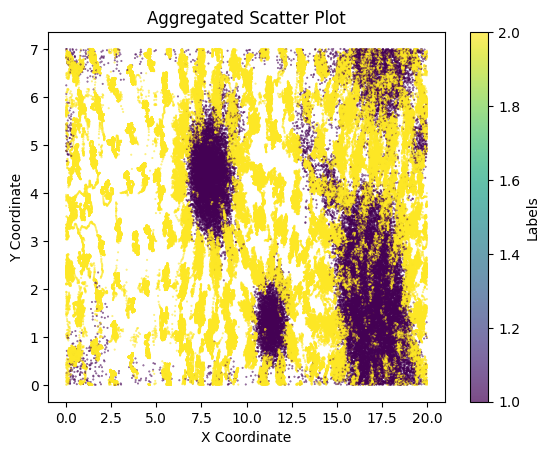

In [19]:
import matplotlib.pyplot as plt

plt.scatter(
    coordinates_array[:, 0], 
    coordinates_array[:, 1], 
    c=labels_array, 
    cmap='viridis', 
    alpha=0.7, 
    s=0.2  # size of the points
)
plt.colorbar(label="Labels")
plt.title("Aggregated Scatter Plot")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

In [1]:
import numpy as np

# Reduce the number of samples and dimensions
graphical_data = np.random.rand(10, 32, 32, 3)  # 10 samples of 32x32 RGB images
numerical_data = np.random.rand(10, 3)          # 10 samples, 3 numerical features
time_series_data = np.random.rand(10, 5, 2)     # 10 samples, 5 time steps, 2 features per step
target_output = np.random.rand(10, 1)           # 10 regression targets


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ graphical_input     │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 62, 62,    │        896 │ graphical_input[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 31, 31,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_series_input   │ (None, 10, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 29, 29,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_input     │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 10, 64)    │     17,408 │ time_series_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 53824)     │          0 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │        384 │ numerical_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 32)        │     12,416 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ graphical_features  │ (None, 128)       │  6,889,600 │ flatten_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_features  │ (None, 32)        │      2,080 │ dense_6[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_series_featur… │ (None, 32)        │      1,056 │ lstm_5[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_features      │ (None, 192)       │          0 │ graphical_featur… │
│ (Concatenate)       │                   │            │ numerical_featur… │
│                     │                   │            │ time_series_feat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │     12,352 │ fused_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,956,801 (26.54 MB)

 Trainable params: 6,956,801 (26.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 293ms/step - loss: 144.7121 - mae: 8.2317 - val_loss: 11.4754 - val_mae: 3.3803
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - loss: 32.1729 - mae: 4.8374 - val_loss: 11.5554 - val_mae: 3.3917
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - loss: 8.0629 - mae: 2.6096 - val_loss: 1.0281 - val_mae: 0.9904
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 0.9228 - mae: 0.8669 - val_loss: 0.1082 - val_mae: 0.2722
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - loss: 1.4072 - mae: 0.9830 - val_loss: 0.0684 - val_mae: 0.2073
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - loss: 0.5703 - mae: 0.6131 - val_loss: 0.0530 - val_mae: 0.1987
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - loss: 0.2787 - mae: 0.4300 - val_loss: 0.0589 - val_mae: 0.1941
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - loss: 0.2141 - mae: 0.3766 - val_loss: 0.0491 - val_mae: 0.1804
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - loss: 0.1683 - 

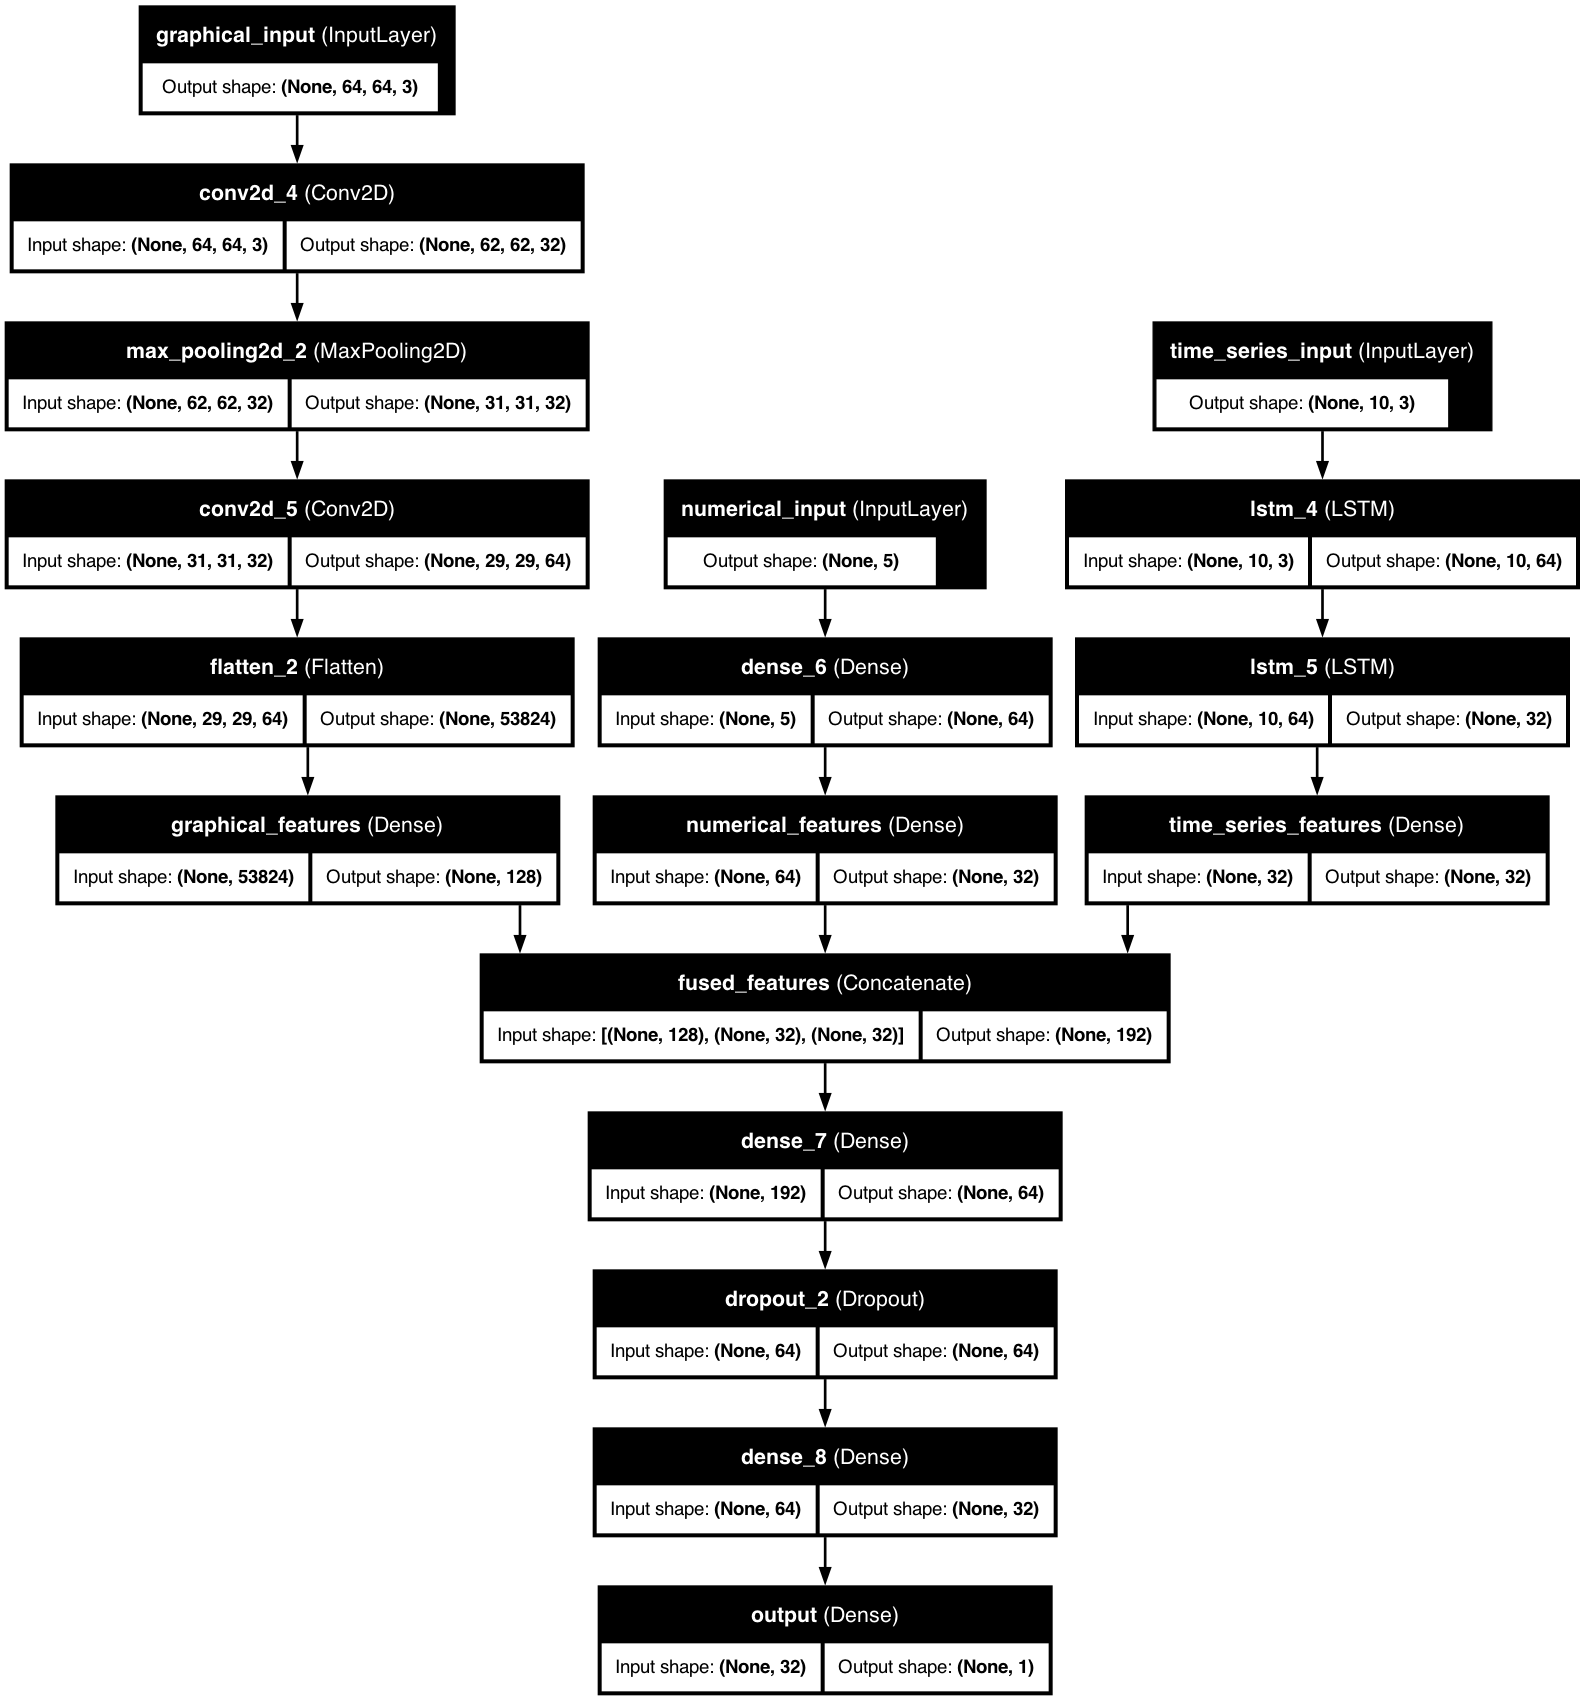

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.utils import plot_model

# Step 1: Dummy Data Preparation
# Generate dummy data for three input types
graphical_data = np.random.rand(100, 64, 64, 3)    # Images
numerical_data = np.random.rand(100, 5)            # Numerical features
time_series_data = np.random.rand(100, 10, 3)      # Time-series data
target_output = np.random.rand(100, 1)             # Target variable

# Step 2: Model Definition
# Graphical branch
graphical_input = Input(shape=(64, 64, 3), name="graphical_input")
x1 = layers.Conv2D(32, (3, 3), activation='relu')(graphical_input)
x1 = layers.MaxPooling2D((2, 2))(x1)
x1 = layers.Conv2D(64, (3, 3), activation='relu')(x1)
x1 = layers.Flatten()(x1)
graphical_features = layers.Dense(128, activation='relu', name="graphical_features")(x1)

# Numerical branch
numerical_input = Input(shape=(5,), name="numerical_input")
x2 = layers.Dense(64, activation='relu')(numerical_input)
numerical_features = layers.Dense(32, activation='relu', name="numerical_features")(x2)

# Time-series branch
time_series_input = Input(shape=(10, 3), name="time_series_input")
x3 = layers.LSTM(64, return_sequences=True)(time_series_input)
x3 = layers.LSTM(32)(x3)
time_series_features = layers.Dense(32, activation='relu', name="time_series_features")(x3)

# Feature Fusion
combined_features = layers.Concatenate(name="fused_features")(
    [graphical_features, numerical_features, time_series_features]
)

# Fully connected layers for prediction
x = layers.Dense(64, activation='relu')(combined_features)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(1, activation='linear', name="output")(x)

# Define the model
model = models.Model(
    inputs=[graphical_input, numerical_input, time_series_input],
    outputs=output
)

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Print model summary
model.summary()

# Step 4: Train the Model
history = model.fit(
    [graphical_data, numerical_data, time_series_data],  # Inputs
    target_output,  # Target
    epochs=20,
    batch_size=16,
    validation_split=0.2
)

# Generate and save the model architecture diagram
plot_model(
    model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=96
)


In [7]:
# Extract latent features from the fused layer
from tensorflow.keras.models import Model

feature_extractor = Model(inputs=model.input, outputs=model.get_layer("fused_features").output)
latent_features = feature_extractor.predict([graphical_data, numerical_data, time_series_data])

# Perform symbolic regression on latent features
import pysr
equations = pysr.PySRRegressor(
    niterations=100,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["exp", "log", "sin", "cos"]
).fit(latent_features, target_output)
print(equations)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step 


/Users/sophia01px2019/miniforge3/envs/new_env/lib/python3.9/site-packages/pysr/sr.py:2582: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/Users/sophia01px2019/miniforge3/envs/new_env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/sophia01px2019/miniforge3/envs/new_env/lib/python3.9/site-packages/pysr/sr.py:2059: UserWarning: Note: you are running with 10 features or more. Genetic algorithms like used in PySR scale poorly with large numbers of features. You should run PySR for more `niterations` to ensure it can find the correct variables, and consider using a larger `maxsize`.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 5.970e+05
Head worker occupation: 19.5%
Progress: 1324 / 1500 total iterations (88.267%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           7.973e-02  1.594e+01  y = 0.55465
2           7.892e-02  1.016e-02  y = sin(x₁₂₇)
3           6.747e-02  1.568e-01  y = 0.47677 * x₅₂
4           5.992e-02  1.187e-01  y = sin(x₅₂ + -0.72982)
5           5.778e-02  3.629e-02  y = 0.71658 * (x₅₂ + x₉₃)
6           5.588e-02  3.342e-02  y = sin(x₅₂ + (x₁₃₉ - x₇₁))
7           5.586e-02  3.703e-04  y = sin(x₅₂ + (sin(x₁₃₉) - x₇₁))
8           5.550e-02  6.477e-03  y = sin(((x₁₃₉ - x₁₆₂) - x₇₁) + x₅₂)
10          5.517e-02  3.007e-03  y = sin(((x₁₃₉ - x₁₆₂) - x₇₁) + x₅₂) + x₁₆₆
11          5.501e-02  2.896e-03  y = ((((x₇₁ * x₁₃₉) - x₁₆₂) - x₇₁) + x₅₂) * 0.83851
12          5.501e-02  3.386e-05  y = sin(0.77348 * (x₅₂ + ((x₁₃₉ - x₅₇) - (x₇₁ * x₇₁))))
13

In [ ]:
# necessary imports and definitions for this section
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import torch.nn as nn
from sklearn.metrics import f1_score
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



#Used this tutorial for help: https://www.digitalocean.com/community/tutorials/writing-cnns-from-scratch-in-pytorch

#Preprocess the images (resize) so they are all the same size (32 x 32)
def toTensor(imageset):
    transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
 
    tensor = [transform(Image.fromarray(image)) for image in imageset]
    return torch.stack(tensor)


# Creating a CNN class
class ConvNeuralNet(nn.Module):

    def __init__(self, num_classes=4): #takes in number of classes, default at 4 for hurricane dataset
        super(ConvNeuralNet, self).__init__()
        #2 layers with a max pooling layer. 3 kernels for RGB data
        self.conv_layer1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(12) 
        self.conv_layer2 = nn.Conv2d(in_channels=12, out_channels=12, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(12)
        self.max_pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.relu1 = nn.ReLU() 
        
        #another 2 layers with a max pooling layer
        self.conv_layer3 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=3, stride=1, padding=1) # 2 more layers with another max pooling layer
        self.bn3 = nn.BatchNorm2d(24)
        self.conv_layer4 = nn.Conv2d(in_channels=24, out_channels=24, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(24)
        self.max_pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.relu2 = nn.ReLU() 

        #another 2 layers with a max pooling layer
        self.conv_layer5 = nn.Conv2d(in_channels=24, out_channels=24, kernel_size=3, stride=1, padding=1) # 2 more layers with another max pooling layer
        self.bn5 = nn.BatchNorm2d(24)
        self.conv_layer6 = nn.Conv2d(in_channels=24, out_channels=24, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(24)
        self.max_pool3 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.relu3 = nn.ReLU() 

        #dropout layer to help with overfitting
        self.drop = nn.Dropout2d(p=0.5)
        
        # 32 x 32 tensor images, pooled 2x with kernel size = 2, so they're now 8x8
        # 8 x 8 x 24 (how many we generated)
        self.fc1 = nn.Linear( 4 * 4 * 24, num_classes) #linear layer that maps to the classes
    
    # Moving images through CNN    
    def forward(self, x): 
        out = self.conv_layer1(x) #first conv layer
        out = self.bn1(out) #batch normalization
        out = self.conv_layer2(out) #second conv layer
        out = self.bn2(out) #batch normalization
        out = self.max_pool1(out) #max pooling layer (dimensionality reduction)
        out = self.relu1(out) #relu activation
        
        out = self.conv_layer3(out) #third conv layer
        out = self.bn3(out) #batch normalization
        out = self.conv_layer4(out) #fourth conv layer
        out = self.bn4(out) #batch normalization
        out = self.max_pool2(out) #max pooling layer (dimensionality reduction)
        out = self.relu2(out) #relu activation

        out = self.conv_layer5(out) #third conv layer
        out = self.bn5(out) #batch normalization
        out = self.conv_layer6(out) #fourth conv layer
        out = self.bn6(out) #batch normalization
        out = self.max_pool3(out) #max pooling layer (dimensionality reduction)
        out = self.relu3(out) #relu activation

       
        out = self.drop(out) #dropout layer
        
        out = out.reshape(out.size(0), -1) # flattens to 1D before feeding to linear layers
        
        out = self.fc1(out) # fully connected layer
        return out




In [ ]:
# loading in the raw images 

disaster_list = ["hurricane-matthew"]

data = {}
split = "train"

with open('config.json') as config_file:
    config = json.load(config_file)
    # data_dir = "/home/jovyan/shared/course/data100-shared-readwrite/fa24_grad_project_data/satellite-image-data"
    data_dir = "../satellite-image-data"

for disaster in disaster_list:
    print(f"Loading {split} images and labels for {disaster} dataset...")
    images = get_images(data_dir, disaster, split=split)
    labels = get_labels(data_dir, disaster, split=split)
    data[disaster] = {"images": images, "labels": labels}

# choose hurricane-matthew from our labels list 
disaster = disaster_list[0]

#separate the labels and the images for our EDA
hurricane_matthew_labels = data[disaster]["labels"]
hurricane_matthew_images = data[disaster]["images"]

In [ ]:
# data cleaning and formatting for the CNN
random_0_indices = list(np.where(hurricane_matthew_labels == 0)[0])
random_1_indices = list(np.where(hurricane_matthew_labels == 1)[0])
random_3_indices = list(np.where(hurricane_matthew_labels == 3)[0])
random_2_indices = list(np.where(hurricane_matthew_labels == 2)[0])

display(len(random_0_indices)) #2631
display(len(random_1_indices)) #5236
display(len(random_2_indices)) #1544
display(len(random_3_indices)) #1740

# loader objects for PyTorch
images_tensor = toTensor(hurricane_matthew_images)
labels_tensor = torch.tensor(hurricane_matthew_labels, dtype = torch.long)


#Split into validation and training sets
X_train_CNN, X_valid_CNN, y_train_CNN, y_valid_CNN = train_test_split(images_tensor, labels_tensor, test_size=0.2, random_state=42)


#Create tensor datasets to load into the loader object
train_dataset = TensorDataset(X_train_CNN, y_train_CNN)
valid_dataset = TensorDataset(X_valid_CNN, y_valid_CNN)

#Create loader objects (preserves memory by only loading the images batch by batch)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=4)


In [ ]:
#finding the proportion of each label

len(hurricane_matthew_labels)
zero = 2631/len(hurricane_matthew_labels)
one = 5236/len(hurricane_matthew_labels)
two = 1544/len(hurricane_matthew_labels)
three = 1740/len(hurricane_matthew_labels)

print(zero)
print(one)
print(two)
print(three)


## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin

#converting my CNN into a form that I can use with GridSearchCV

class PyTorchCNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, num_classes=4, learning_rate=0.001, weight_decay=1e-4, momentum=0.9, num_epochs=50, batch_size=32):
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.momentum = momentum
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = ConvNeuralNet(num_classes=num_classes).to(self.device)
        self.loss_func = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.SGD(self.model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)

    def fit(self, X, y):
        train_dataset = TensorDataset(X, y)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=4)

        for epoch in range(self.num_epochs):
            self.model.train()
            running_loss = 0.0
            correct_train = 0
            total_train = 0

            for images, labels in train_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(images)
                loss = self.loss_func(outputs, labels)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                running_loss += loss.item()
                _, predicted_train = torch.max(outputs.data, 1)
                total_train += labels.size(0)
                correct_train += (predicted_train == labels).sum().item()

            avg_loss = running_loss / len(train_loader)
            t_accuracy = 100 * correct_train / total_train

        return self

    def predict(self, X):
        self.model.eval()
        X = X.to(self.device)
        outputs = self.model(X)
        _, predicted = torch.max(outputs.data, 1)
        return predicted.cpu().numpy()

    def score(self, X, y):
        y_pred = self.predict(X)
        return f1_score(y.cpu().numpy(), y_pred, average='weighted')


# Define the parameters I want to test

param_grid = {
    'learning_rate': [0.001, 0.01, 0.1],
    'weight_decay': [1e-4, 1e-5],
    'momentum': [0.9, 0.95]
}

# initialize the custom class
cnn_estimator = PyTorchCNNClassifier()

# initialize and run GridSearchCV
grid_search = GridSearchCV(estimator=cnn_estimator, param_grid=param_grid, scoring='f1_weighted', cv=3, n_jobs=1)
grid_search.fit(X_train_CNN, y_train_CNN)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Best score
print("Best score: ", grid_search.best_score_)


In [ ]:

# hyperparameters 
num_classes = 4 #number of classes in our dataset
learning_rate = 0.001 #initializing initial learning rate

# set device to run 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#setting up model using our custom class
cnn_model_11 = ConvNeuralNet(num_classes)

# using cross entropy for the loss function
class_weights = torch.tensor([0.23594296475652407, 0.46955430006277465, 0.13846291812393507, 0.1560398170567662], device=device)
loss_func = nn.CrossEntropyLoss(weight=class_weights)

# set optimizer for CNN (stochastic gradient descent)
optimizer = torch.optim.SGD(cnn_model_11.parameters(), lr=learning_rate, weight_decay = 1e-4, momentum = 0.9)

#takes ~20 mins to run!
num_epochs = 50 #number of times to run the CNN


In [ ]:
#Counters for visualization of training loss and accuracy
train_loss = []
train_accuracy = []
train_f1 = []


for epoch in range(num_epochs):
    #training mode
    cnn_model_11.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    true_labels = []
    pred_labels = []

    # user loader object to load the data
    for i, (images, labels) in enumerate(train_loader):  
        # Move tensors to the configured device
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward through the CNN
        outputs = cnn_model_11(images) 
        loss = loss_func(outputs, labels) #calculate loss
        
        # Backpropagation, optimize parameters
        optimizer.zero_grad() #use SGD to optimize weights
        loss.backward() #check new gradient with loss function
        optimizer.step() #update weights

        running_loss += loss.item() #add all loss over this loop to running_loss

        _, predicted_train = torch.max(outputs.data, 1) # get current prediction for this epoch
        total_train += labels.size(0)
        correct_train += (predicted_train == labels).sum().item() #compare prediction with label

        true_labels.extend(labels.cpu().numpy()) #adding true labels to a flat list
        pred_labels.extend(predicted_train.cpu().numpy()) #adding pred labels to a flat list
    

    
    # Calculate average loss and accuracy over the epoch
    avg_loss = running_loss / len(train_loader) #gives the average loss over the epoch
    train_loss.append(avg_loss)
    t_accuracy = 100 * correct_train / total_train
    train_accuracy.append(t_accuracy)
    train_f1.append(f1_score(true_labels, pred_labels, average='weighted'))
    
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {train_accuracy[-1]:.2f}%, F1 Score: {train_f1[-1]:.4f}')


In [ ]:
#Running validation set through the optimized CNN to calculate accuracy

cnn_model_11.eval() #model in evaluation mode


#collecting metrics from validation evaluation run as well
valid_running_loss = 0.0
correct_valid = 0
total_valid = 0
true_labels_valid = []
pred_labels_valid = []

#do not need gradient optimization for validation set
with torch.no_grad(): 
    for images, labels in valid_loader: 
        images = images.to(device)
        labels = labels.to(device)
        outputs = cnn_model_11(images)

        #loss
        loss = loss_func(outputs, labels)
        valid_running_loss += loss.item()

        #accuracy
        _, predicted_valid = torch.max(outputs.data, 1)
        total_valid += labels.size(0)
        correct_valid += (predicted_valid == labels).sum().item()

        true_labels_valid.extend(labels.cpu().numpy())
        pred_labels_valid.extend(predicted_valid.cpu().numpy())

avg_valid_loss = valid_running_loss / len(valid_loader)
valid_accuracy =  100 * correct_valid / total_valid
valid_f1 = f1_score(true_labels_valid, pred_labels_valid, average='weighted')
    
print(f'Validation Loss: {avg_valid_loss:.4f}')
print(f'Validation Accuracy: {valid_accuracy:.2f}%')
print(f'Validation F1 Score: {valid_f1:.4f}')

In [ ]:
#Visualization of training loss and accuracy

xplot = np.arange(num_epochs)

fig1, ax1 = plt.subplots(2, 1, sharex = True)
ax1[0].set_title("Training metrics for Hurricane Matthew data")
ax1[0].plot(xplot, train_loss, 'blue', label="Training Loss")
ax1[0].set_ylabel('Loss')
ax1[0].legend()
ax1[1].plot(xplot, train_accuracy, 'red', label='Training Accuracy')
ax1[1].set_ylabel('Accuracy [%]')
ax1[1].legend()
plt.xlabel('Epochs')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

train_cm = confusion_matrix(true_labels, pred_labels)
test_cm = confusion_matrix(true_labels_valid, pred_labels_valid)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(train_cm, display_labels=[0, 1, 2, 3]).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Hurricane Training Set Confusion Matrix")
ConfusionMatrixDisplay(test_cm, display_labels=[0, 1, 2 ,3]).plot(ax=ax[1], colorbar=False)
ax[1].set_title("Hurricane Validation Set Confusion Matrix")

plt.show()

## Performance Assessment

Use the model to generate predictions for the `test_images_hurricane-matthew.npz` images. This should be in a CSV file `test_images_hurricane-matthew_predictions.csv` consisting of a single column with no header, with a 0-3 prediction of the damage level. The prediction in row *i* should correspond to the *i*th image.

In [ ]:
test_im_hurricane_path = os.path.join(data_dir, "test_images_hurricane-matthew.npz")
test_im_hurricane = load_images(test_im_hurricane_path)

In [ ]:
plt.imshow(test_im_hurricane[0]);

In [ ]:
test_sobel_edges = img_to_sobel(test_im_hurricane)
test_lbp = img_to_LBP(test_im_hurricane)  
test_red, test_green, test_blue = image_to_RGB(test_im_hurricane)
test_red_log = np.log(np.array(test_red))
test_green_log = np.log(np.array(test_green))
test_blue_log = np.log(np.array(test_blue))  # not used, keeping for consistency
test_gabor = img_to_gabor(test_im_hurricane)

# Combine all features into df
test_features = pd.DataFrame({
    'Sobel_Edges': test_sobel_edges,
    "LBP": test_lbp,
    'Red_Log': test_red_log,
    'Green_Log': test_green_log,
    'Gabor': test_gabor
})

## Logistic

In [ ]:
test_predictions = model.predict(test_features)
output_path = "logistic_test_images_hurricane_predictions.csv"
pd.DataFrame(test_predictions).to_csv(output_path, index=False, header=False)

## Gradient

In [ ]:
pca_test = pca_hur.transform(test_features)

test_predictions = predict(pca_test, weights, bias)

output_path = "gradient_logistic_test_images_hurricane_predictions.csv"
pd.DataFrame(test_predictions).to_csv(output_path, index=False, header=False)

print(f"Predictions saved to {output_path}")

## CNN

In [ ]:
# Define a loader for the test dataset
test_images = resize(test_im_hurricane)
test_features = toTensor(test_images)

test_dataset = TensorDataset(test_features)

test_loader =  DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

cnn_model_11.eval() #model in test mode

test_predictions = []

#do not need gradient optimization 
with torch.no_grad(): 
    for images in test_loader: 
        images = images[0].to(device)
        outputs = cnn_model_11(images)

        _, predicted = torch.max(outputs.data, 1)

        test_predictions.extend(predicted.cpu().numpy())

output_path = "cnn_test_images_hurricane-matthew_predictions_v2.csv"
predictions_df = pd.DataFrame(test_predictions, columns=["pred"])
predictions_df.to_csv(output_path, index=False)

print(f"Predictions saved to {output_path}")